In [1]:
# ============================================================================
# AUTORELOAD  — pick up .py edits without restarting the kernel
# ============================================================================
# Python caches imported modules in `sys.modules`. If you edit `src/config.py`
# while this notebook's kernel is running, the cached old version keeps
# getting used until you restart the kernel — a classic 'why isn't my change
# showing up?' source of confusion.
#
# `%load_ext autoreload` loads IPython's autoreload extension, and
# `%autoreload 2` tells it: 'before each cell run, silently re-import any
# module whose source file has changed on disk'. Zero-effort hot-reload.
#
# The `%` prefix makes these IPython MAGIC commands, not Python — they only
# work inside Jupyter / IPython, not in plain .py scripts.

%load_ext autoreload
%autoreload 2

In [2]:
import sys
print(sys.executable)

/Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/.venv/bin/python


# 01 — Data Exploration (RAW, pre-cleaning)

## What is this notebook for? (donkey version)

Before we build ANY model, we need to actually **look at our data**. Think of it like this: a doctor doesn't prescribe medicine without first checking your temperature, blood pressure, and asking what hurts. In the same way, we don't write a cleaning function (`clean_text`) without first seeing what kind of dirt is actually on our data.

**Why this matters:** it's super tempting to copy-paste a 'standard tweet cleaner' from a blog post — strip URLs, strip @mentions, strip hashtags, lowercase everything. But what if our data has ZERO URLs? Then those regex lines are wasted CPU. What if our data is 40% English mixed in? Then stripping non-Devanagari would nuke half the dataset. We don't know until we look.

## What we'll find out for each dataset

1. **Shape & structure** — how many rows, what columns, what data types
2. **Nulls & duplicates** — is the data dirty in obvious ways?
3. **Class distribution** — is one label way more common than others? (affects training)
4. **Length distribution** — are texts short tweets or long reviews? (affects NepBERTa's `max_length`)
5. **Noise audit** — how many rows actually contain URLs, @mentions, #hashtags, emojis?
6. **Script mix** — how Devanagari-pure is the text? Any English sneaking in?
7. **Eyeball samples** — read a few rows per class to catch things numbers miss

**Ground rule:** everything in this notebook runs on RAW text. We do NOT clean, do NOT remap labels, do NOT split train/test. This is pure observation. Plots save to `outputs/figures/` at 300 DPI because CLAUDE.md says so.

In [3]:
# ============================================================================
# IMPORTS  — bring in the libraries we'll need
# ============================================================================
# An 'import' statement tells Python: 'go find this library and make it
# available in this file under this name'. It's like the 'require' in Node.js.

# pandas = the 'Excel of Python'. Its main object is a DataFrame (a table with
# named columns) and a Series (a single labelled column). EVERY time we load
# a CSV, we get a DataFrame back. 99% of data science in Python is just
# pushing DataFrames around. `as pd` is a universally used short alias.
import pandas as pd

# matplotlib is THE plotting library for Python. `pyplot` is its MATLAB-style
# interface — you call functions like `plt.bar()`, `plt.hist()`, `plt.savefig()`.
# Aliased as `plt` by convention. You will see this everywhere in ML code.
import matplotlib.pyplot as plt

# (We don't need to import `numpy` or `re` directly: pandas handles percentiles
# internally, and `Series.str.contains(..., regex=True)` consumes regex
# patterns as plain strings — no explicit `import re` required.)

# `os` = operating-system utilities. We use it for joining folder paths in a
# cross-platform way (forward slashes on Mac/Linux, backslashes on Windows)
# and for creating the outputs/figures/ folder if it doesn't exist.
import os


# ============================================================================
# MAKE `src.config` IMPORTABLE FROM THIS NOTEBOOK
# ============================================================================
# ⚠️ Gotcha: Python can only import modules that are on its 'import path'
# (called `sys.path`). When Jupyter starts in the `notebooks/` folder, the
# PROJECT ROOT (one level up, where `src/` lives) is NOT on the path by
# default — so `from src import config` would fail with ModuleNotFoundError.
# We fix that by adding the project root to sys.path ourselves, at the top.

import sys
# `pathlib.Path` is the modern, object-oriented way to handle file paths.
# `Path.cwd()` = 'current working directory' — where Jupyter was launched from.
from pathlib import Path

cwd = Path.cwd()
# If the notebook is being run from inside notebooks/, project root is up one
# level. Otherwise assume we're already at project root. Handles both launch styles.
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd

# `sys.path.insert(0, ...)` adds a directory to the FRONT of the import path
# (so it's checked before system paths). The `if not in` check avoids adding
# the same path twice if we re-run this cell.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Now this works: Python can find src/config.py because PROJECT_ROOT is on
# sys.path and src/ has an __init__.py (which marks it as a 'package').
from src import config

# `os.makedirs(..., exist_ok=True)` creates the folder (and any missing parent
# folders) — but doesn't complain if it's already there. Safer than checking
# first and creating afterwards.
os.makedirs(config.FIGURES, exist_ok=True)

# Sanity-print the paths. If any of these look wrong, STOP and debug before
# running the rest of the notebook — bad paths cause confusing errors later.
print('Project root:', PROJECT_ROOT)
print('Primary CSV :', config.PRIMARY_RAW_CSV)
print('Figures dir :', config.FIGURES)

Project root: /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis
Primary CSV : /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/data/raw/aayamoza.csv
Figures dir : /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/outputs/figures


## Primary dataset — aayamoza

**Source:** Kaggle (`aayamoza/nepali-sentiment-analysis`). Publicly available collection combining YouTube comments, movie reviews, and other social-media posts in Nepali.

**What we expect (from `head -5` earlier):** columns = `Sentences`, `Sentiment`. Labels already numeric. Long-form comments (not short tweets). Pure Devanagari in the samples we saw.

**What we're about to verify:** are those first-5 observations actually representative? Or do things get weirder further down?

In [4]:
# ============================================================================
# LOAD  —  just read the raw CSV, no transformations yet
# ============================================================================
# `pd.read_csv` parses a comma-separated-values file into a DataFrame.
# It auto-detects column names from the first row (the 'header').
# Behind the scenes it infers data types too (int for whole numbers, object
# for strings, float for decimals, etc).
#
# We pass `config.PRIMARY_RAW_CSV` (= data/raw/aayamoza.csv) instead of a
# hard-coded string. Central config = one place to change if the file moves.
primary_raw = pd.read_csv(config.PRIMARY_RAW_CSV)

# `.shape` is a TUPLE: (num_rows, num_columns). Same as numpy arrays.
# We print it first because it's the single most useful number for sanity-
# checking a load: 'did I get 35k rows like I expected, or 5 because the file
# was half-downloaded?'
print('Shape  :', primary_raw.shape)

# `.columns` is an Index object (list-like) of column names. Wrapping in list()
# makes the print prettier (plain Python list instead of pandas Index repr).
print('Columns:', list(primary_raw.columns))
print()

# `.dtypes` shows the inferred data type of each column. Watch out for:
#   - `object` dtype = usually a string (or mixed types), pandas is vague here
#   - numeric labels coming in as `float64` because of NaN rows (int can't hold NaN)
# If the label column is `object` instead of int, it means the CSV mixed
# strings and numbers — we'd need to clean that.
print('Dtypes:')
print(primary_raw.dtypes)
print()

# `.head(n)` shows the first n rows. Default is 5, we ask for 3 to save space.
# Leaving this expression as the last line of the cell makes Jupyter auto-render
# it as a nice HTML table (rather than boring text).
print('First 3 rows:')
primary_raw.head(3)

Shape  : (35789, 3)
Columns: ['Unnamed: 0', 'Sentences', 'Sentiment']

Dtypes:
Unnamed: 0     int64
Sentences     object
Sentiment      int64
dtype: object

First 3 rows:


,Unnamed: 0,Sentences,Sentiment
0,0,"म एक शिक्षक , शिक्षा क्षेत्रमा रमाएको मान्छे ।...",1
1,1,म सरकारी स्कूल/कलेजमा पढेर करीब १२ बर्ष भन्दा ...,1
2,2,कति राम्रो शिव मन्दिर देख्न पाइयो कुन ठाउको हो...,1


In [5]:
# ============================================================================
# NULLS & DUPLICATES  — the two classic 'dirty data' problems
# ============================================================================
#
# CONCEPT: NULL (NaN in pandas-land)
# -----------------------------------
# A null means 'this cell had nothing in it'. For text data, a null in the
# `Sentences` column = an empty comment. For labels, a null in `Sentiment` =
# no annotation. Either way, that row is useless for supervised training
# because we NEED both (input) AND (label) to learn the mapping between them.
# We'll have to drop these rows later in preprocessing.
#
# `.isnull()` returns a DataFrame of the SAME shape but with True/False
# indicating 'is this cell null?'. Chain `.sum()` and, since True=1 and
# False=0 when summed, you get the count of nulls PER COLUMN.

print('Nulls per column:')
print(primary_raw.isnull().sum())
print()

# CONCEPT: DUPLICATES
# -------------------
# Duplicates are sneakier than nulls. If the SAME text+label pair appears
# multiple times and we split into train+test randomly, some duplicates end
# up in BOTH sets. The model 'memorises' them during training, then aces them
# on the test set — giving us inflated test accuracy that doesn't reflect
# real-world performance. This is called DATA LEAKAGE, and it's the #1 way
# beginner ML projects lie to themselves.
#
# We check two things:
#   (1) Fully identical rows — every column matches. These are pure duplicates.
#   (2) Duplicate TEXT regardless of label — sometimes same text has different
#       labels (annotator disagreement) — those are ambiguous and worth a look.
#
# `.duplicated()` returns a boolean Series: True for every row AFTER the first
# time a value appeared. `.sum()` counts how many Trues there are.

# Check duplicates ignoring the junk index column.
# subset=[...] tells pandas: "only look at these columns when deciding if rows are dupes"
n_dup_text_and_label = primary_raw.duplicated(subset=['Sentences', 'Sentiment']).sum()
n_dup_text_only      = primary_raw.duplicated(subset=['Sentences']).sum()

print(f'Dupes on (text + label):  {n_dup_text_and_label}')
print(f'Dupes on (text only):     {n_dup_text_only}')
print(f'Rows with SAME text but DIFFERENT label:  '
      f'{n_dup_text_only - n_dup_text_and_label}')

# To actually SEE the conflicting ones:
conflicts = (
    primary_raw
    .groupby('Sentences')['Sentiment']
    .nunique()           # how many DISTINCT labels does each text have?
    .loc[lambda s: s > 1]  # keep only texts with >1 distinct label
)
print(f'\nUnique texts with conflicting labels: {len(conflicts)}')
if len(conflicts) > 0:
    # Show a few examples side-by-side
    sample_texts = conflicts.index[:5]
    for t in sample_texts:
        labels = primary_raw.loc[primary_raw['Sentences'] == t, 'Sentiment'].tolist()
        print(f'  labels={labels} | text={t[:100]}...')


Nulls per column:
Unnamed: 0    0
Sentences     0
Sentiment     0
dtype: int64

Dupes on (text + label):  38
Dupes on (text only):     57
Rows with SAME text but DIFFERENT label:  19

Unique texts with conflicting labels: 19
  labels=[-1, 1] | text=अहिले पनि झण्डै डेढ सय आयोजनामा एक लाख हजार कामदार निर्माणस्थलमा रहेको नेपाल निर्माण व्यवयासी महासंघ...
  labels=[-1, 1] | text=आज पनि नयाँ कोभिड पोजेटिभ नदेखिएको स्वास्थ्य तथा जनसँख्या मन्त्रालयका प्रवक्ता डा बिकास देवकोटाद्वार...
  labels=[-1, 0] | text=कोभिड द्धारा नेपालमा सृजित हुने प्रभावबारे त्रिविले अध्ययन तथा अनुशन्धान गर्ने...
  labels=[1, 0] | text=कोभिड रोकथामका लागि बुधबार के के भए...
  labels=[1, -1] | text=कोभिड ले स्वास्थ्य खर्च अकासिने अर्थतन्त्र मन्दीमा...


In [6]:
# ============================================================================
# DUPLICATE AUDIT WITH ROW INDEXES  — find the actual rows in the CSV
# ============================================================================
#
# Above we learned: 38 exact (text+label) dupes + 19 conflicting (same text,
# different label) rows. Knowing the COUNT is not enough — we also want to
# SEE the rows so we can open the CSV and verify them by eye.
#
# We print TWO indexes for every row:
#   - pandas_idx = the row's position in the loaded DataFrame (usually 0..n-1).
#                  Use `primary_raw.loc[<n>]` in a new cell to pull that row.
#   - csv_idx    = the value in the `Unnamed: 0` column, which matches the
#                  first column inside data/raw/aayamoza.csv. Open the CSV in
#                  VS Code / a text editor and jump to that row to inspect.
#
# ⚠️ NUMBER MISMATCH WARNING (why this cell's total != previous cell's total)
# -----------------------------------------------------------------------------
# Previous cell:  "Dupes on (text + label): 38"     ← uses keep='first' (default)
# This cell:      "— 76 rows"                        ← uses keep=False
#
# Both are correct — they answer different questions:
#   keep='first'  → flags only the 2nd+ occurrence of each dup group
#                   ('how many rows would drop_duplicates() remove?')
#   keep=False    → flags every row that belongs to ANY dup group
#                   ('how many rows are involved in any duplication at all?')
#
# Concrete: if a text+label appears twice, keep='first' flags 1 row, keep=False
# flags 2. So 38 groups × 2 rows-per-group = 76. Not a bug — a deliberate
# choice so each pair prints SIDE-BY-SIDE below, which is what you want for
# eyeballing "original vs copy" in the CSV. Same logic applies to the
# conflicting-rows table below (19 unique texts → 39 rows because one text
# appears 3 times, the rest appear twice).

# --- (A) Harmless exact duplicates ------------------------------------------
# `keep=False` flags ALL occurrences of each duplicate group (not just the
# 2nd+), so you see the entire group side-by-side.
# `sort_values('Sentences')` puts identical texts next to each other so the
# printed block reads naturally.
exact_dup_mask = primary_raw.duplicated(subset=['Sentences', 'Sentiment'], keep=False)
exact_dup_rows = primary_raw[exact_dup_mask].sort_values('Sentences')

# Print both numbers up-front so the 38-vs-76 difference is obvious, not
# something you have to figure out after the fact.
n_repeats = primary_raw.duplicated(subset=['Sentences', 'Sentiment']).sum()  # keep='first'
print(f'Repeat rows (keep="first"):   {n_repeats}   ← how many would drop on dedup')
print(f'All dup rows (keep=False):    {len(exact_dup_rows)}   ← every row in a dup group')
print()

print(f'── (A) Exact duplicates (text + label match) — {len(exact_dup_rows)} rows ──')
print('(pandas_idx, csv_idx, label, text[:60])')
# `.iterrows()` yields (index, row_Series) pairs. Capped at 30 rows to avoid
# a wall-of-text in the notebook.
for pandas_idx, row in exact_dup_rows.head(30).iterrows():
    # Strip newlines from the snippet so each row prints on ONE line.
    text_snippet = row['Sentences'][:60].replace('\n', ' ')
    print(f'  [{pandas_idx:>6}]  csv_idx={row["Unnamed: 0"]:<6} '
          f'label={row["Sentiment"]:>2}  {text_snippet}...')
if len(exact_dup_rows) > 30:
    print(f'  ... showing first 30 of {len(exact_dup_rows)}.')
print()

# --- (B) Conflicting rows (same text, different labels) ---------------------
# Rebuild the conflict-text list here so this cell is self-contained (doesn't
# silently depend on a variable from the previous cell still being in memory).
conflict_texts = (
    primary_raw.groupby('Sentences')['Sentiment']
    .nunique()
    .loc[lambda s: s > 1]
    .index
)

# Pull EVERY row whose text is in the conflict set, then sort by text then
# label so each disagreement group appears together in the print.
conflict_rows = (
    primary_raw[primary_raw['Sentences'].isin(conflict_texts)]
    .sort_values(['Sentences', 'Sentiment'])
)

print(f'── (B) Conflicting rows (same text, ≥2 labels) — {len(conflict_rows)} rows '
      f'across {len(conflict_texts)} unique texts ──')
print('(pandas_idx, csv_idx, label, text[:80])')
for pandas_idx, row in conflict_rows.iterrows():
    text_snippet = row['Sentences'][:80].replace('\n', ' ')
    print(f'  [{pandas_idx:>6}]  csv_idx={row["Unnamed: 0"]:<6} '
          f'label={row["Sentiment"]:>2}  {text_snippet}...')

# --- Quick-lookup recipes ---------------------------------------------------
#   primary_raw.loc[12345]                       # one row by pandas_idx
#   primary_raw.loc[[12, 34, 56]]                # several rows by pandas_idx
#   primary_raw[primary_raw['Unnamed: 0'] == 42] # one row by csv_idx

Repeat rows (keep="first"):   38   ← how many would drop on dedup
All dup rows (keep=False):    76   ← every row in a dup group

── (A) Exact duplicates (text + label match) — 76 rows ──
(pandas_idx, csv_idx, label, text[:60])
  [  1934]  csv_idx=1436   label= 0  असली मायामा कचेरा पुछ्दै भिडियोकल गरिन्छ...
  [   947]  csv_idx=394    label= 0  असली मायामा कचेरा पुछ्दै भिडियोकल गरिन्छ...
  [    18]  csv_idx=19     label=-1  अहिले सम्मको झल्लो फिल्म राम्रो नि लागेन...
  [   226]  csv_idx=228    label=-1  अहिले सम्मको झल्लो फिल्म राम्रो नि लागेन...
  [   477]  csv_idx=493    label= 1  एउटा नया इतिहास लेख्यो यो फिल्म ले यती धेरै  राम्रो फिल्म ने...
  [   230]  csv_idx=232    label= 1  एउटा नया इतिहास लेख्यो यो फिल्म ले यती धेरै  राम्रो फिल्म ने...
  [   479]  csv_idx=495    label=-1  एउटाको गलती अर्कोलाई सजाय यो भएन यथार्थमा आधारित बनाउनु पर्य...
  [   436]  csv_idx=450    label=-1  एउटाको गलती अर्कोलाई सजाय यो भएन यथार्थमा आधारित बनाउनु पर्य...
  [   224]  csv_idx=226    label= 1  एक सय एक

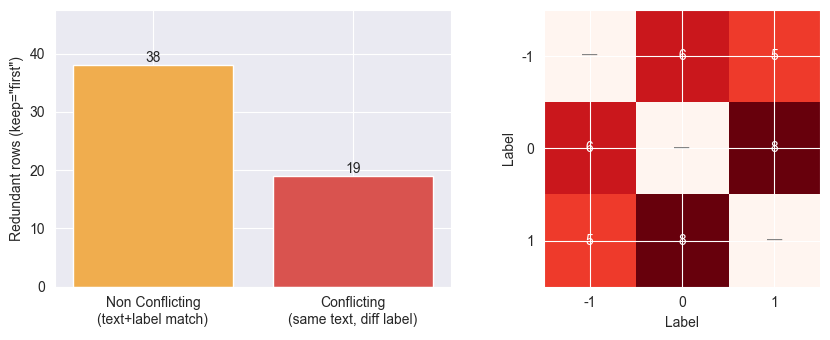

Total rows: 35,789
Text-duplicate rows (keep="first"):  57
  Agreeing (harmless, dropable):     38
  Conflicting (needs resolution):    19

Reading panel B:
  Each off-diagonal cell = count of UNIQUE texts that received both
  labels. Heatmap is symmetric, so cell (i,j) == cell (j,i). The
  (-1, 1) corner being nonzero is the worst case: the same sentence
  was annotated both Negative AND Positive.


In [7]:
# ============================================================================
# DATA QUALITY VISUALIZATION  — duplicates + conflicting labels at a glance
# ============================================================================
#
# Why a figure, not just a table?
# --------------------------------
# We found 38 exact-duplicate rows and 19 conflicting-label rows in the
# previous cells.
# We need exactly one figure that answers two questions at once:
#
#   Panel (A): 'of all duplicated rows, how many are harmless (agreeing
#              labels) vs. problematic (conflicting labels)?'
#   Panel (B): 'when labels conflict, WHICH labels disagree with WHICH?'
#              Sharp disagreements (Positive vs Negative) are worse than
#              mild ones (Neutral vs Positive) because they suggest either
#              annotation error OR genuinely ambiguous text — both hurt
#              training, but the former is a louder alarm.

# itertools.combinations = stdlib helper for enumerating unordered pairs.
# Given [a, b, c] it yields (a,b), (a,c), (b,c) — we use it to convert a
# text's list of distinct labels into every disagreeing pair.
from itertools import combinations

# --- stats (recomputed so this cell is self-contained) ---------------------
# Using keep='first' (the default) so "redundant" means "rows that would
# disappear if we called drop_duplicates()". These are the rows that are
# actually problematic — every text's FIRST occurrence is treated as canonical.
n_total         = len(primary_raw)
n_exact_repeats = primary_raw.duplicated(subset=['Sentences', 'Sentiment']).sum()  # 38
n_text_repeats  = primary_raw.duplicated(subset=['Sentences']).sum()               # 57
n_conflict_reps = n_text_repeats - n_exact_repeats                                  # 19

# --- label-pair co-occurrence for the conflicting texts --------------------
# Rebuild the conflict-text list (we defined it in a previous cell, but
# re-deriving keeps this cell runnable on its own).
conflict_texts = (
    primary_raw.groupby('Sentences')['Sentiment']
    .nunique()
    .loc[lambda s: s > 1]
    .index
)

# Build a 3x3 DataFrame of zeros, indexed/columned by the raw labels.
# For each conflicting text, take the set of distinct labels it received,
# and for every PAIR in that set bump both (a, b) AND (b, a) — so the
# heatmap is symmetric and either triangle tells the same story.
RAW_LABELS = [-1, 0, 1]
pair_counts = pd.DataFrame(0, index=RAW_LABELS, columns=RAW_LABELS)
for t in conflict_texts:
    # .unique() gives distinct labels for this text; sort so (a,b) is
    # deterministic when we loop over pairs.
    distinct_labels = sorted(primary_raw.loc[primary_raw['Sentences'] == t, 'Sentiment'].unique())
    for a, b in combinations(distinct_labels, 2):
        pair_counts.loc[a, b] += 1
        pair_counts.loc[b, a] += 1

# --- figure: 1 row, 2 panels ------------------------------------------------
fig, (ax_bar, ax_hm) = plt.subplots(1, 2, figsize=(9, 3.5))

# ── Panel A — redundant-row breakdown ─────────────────────────────────────
# Two bars: agreeing (harmless) vs. conflicting (has to be resolved).
# Orange = 'annoying but safe to drop'. Red = 'ambiguous, needs a decision'.
categories = ['Non Conflicting\n(text+label match)', 'Conflicting\n(same text, diff label)']
values     = [n_exact_repeats, n_conflict_reps]
colors     = ['#f0ad4e', '#d9534f']

bars = ax_bar.bar(categories, values, color=colors, edgecolor='white')
# Annotate each bar with the count — redundant with y-axis but saves eye travel.
for bar, v in zip(bars, values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, v, str(v),
                ha='center', va='bottom', fontsize=10)
ax_bar.set_ylabel('Redundant rows (keep="first")')
# Give the tallest bar ~20% headroom so the annotation doesn't clip.
ax_bar.set_ylim(0, max(values) * 1.25)

# ── Panel B — label-pair disagreement heatmap ─────────────────────────────
# Reds colormap (light = few conflicts, dark = many). Off-diagonal cells are
# annotated with the raw count. The diagonal is shown as '—' because a text
# with 'same label twice' is by definition NOT a conflict — already lives
# in Panel A's 'Agreeing' bar.
im = ax_hm.imshow(pair_counts.values, cmap='Reds', vmin=0)
ax_hm.set_xticks(range(3)); ax_hm.set_xticklabels(RAW_LABELS)
ax_hm.set_yticks(range(3)); ax_hm.set_yticklabels(RAW_LABELS)
ax_hm.set_xlabel('Label')
ax_hm.set_ylabel('Label')

# Choose text color per cell: white on dark cells, black on light cells.
# This keeps the annotations readable regardless of Reds scaling.
vmax = pair_counts.values.max() or 1  # avoid divide-by-zero if ever empty
for i in range(3):
    for j in range(3):
        v = pair_counts.values[i, j]
        if i == j:
            ax_hm.text(j, i, '—', ha='center', va='center', color='grey', fontsize=11)
        else:
            ax_hm.text(j, i, int(v), ha='center', va='center',
                       color='white' if v > vmax / 2 else 'black', fontsize=10)

plt.tight_layout()
# Save to outputs/figures/ at 300 DPI per CLAUDE.md.
plt.savefig(os.path.join(config.FIGURES, 'data_quality_primary.png'),
            dpi=config.FIGURE_DPI)
plt.show()

# --- summary print (so the exact numbers are next to the plot in the nb) ---
print(f'Total rows: {n_total:,}')
print(f'Text-duplicate rows (keep="first"):  {n_text_repeats}')
print(f'  Agreeing (harmless, dropable):     {n_exact_repeats}')
print(f'  Conflicting (needs resolution):    {n_conflict_reps}')
print()
print('Reading panel B:')
print('  Each off-diagonal cell = count of UNIQUE texts that received both')
print('  labels. Heatmap is symmetric, so cell (i,j) == cell (j,i). The')
print('  (-1, 1) corner being nonzero is the worst case: the same sentence')
print('  was annotated both Negative AND Positive.')

Raw label counts:
  label=  -1:   14408  (40.3%)
  label=   0:    5501  (15.4%)
  label=   1:   15880  (44.4%)


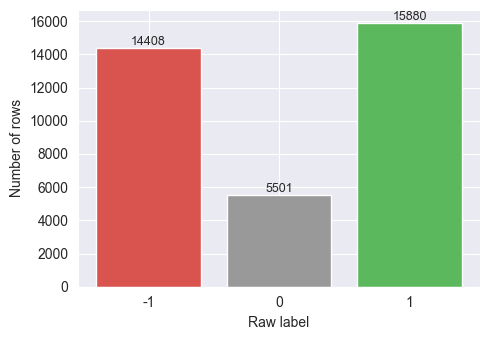

In [8]:
# ============================================================================
# CLASS DISTRIBUTION  — how many of each label do we have?
# ============================================================================
#
# CONCEPT: CLASS IMBALANCE
# ------------------------
# Imagine 70% of your data is labelled 'Neutral'. A lazy model can just always
# predict 'Neutral' and score 70% accuracy while learning nothing. That's the
# imbalance trap. If we find heavy imbalance here, we'll need:
#   - `class_weight='balanced'` in Logistic Regression
#   - weighted cross-entropy loss in NepBERTa
#   - per-class precision/recall/F1 in evaluation (NOT just accuracy)
# This EDA step decides whether all of that is necessary or overkill.
#
# `.value_counts()` is pandas's 'group by and count' for a single column.
# It returns a Series with unique values as the index and counts as values,
# by default sorted by count descending.
#
# We call `.sort_index()` afterwards to re-sort by the LABEL value (-1, 0, 1)
# rather than by count — this makes the output easier to scan and the bar chart
# consistent across datasets (Negative on the left, Positive on the right).

primary_label_counts = primary_raw['Sentiment'].value_counts().sort_index()

# CONCEPT: COUNT  -> PERCENTAGE
# -----------------------------
# Raw counts are hard to eyeball. '5234 negative' — is that a lot? Out of
# 35794 rows, yes-ish (~15%). Out of 100k, not really (~5%). So we ALSO
# compute percentages. The formula is (count / total * 100), rounded to one
# decimal place because nobody cares about 60.483% vs 60.5%.
#
# Pandas 'broadcasting' means dividing a Series by a scalar divides every
# value — no explicit loop needed. Same for multiplying by 100.
primary_label_pct = (primary_label_counts / len(primary_raw) * 100).round(1)

print('Raw label counts:')
# `.items()` iterates over (index, value) pairs. `!s:>4` = 'format as string,
# right-justify in a 4-char field'. Gives aligned columns in the printout.
for lbl, cnt in primary_label_counts.items():
    print(f'  label={lbl!s:>4}:  {cnt:>6}  ({primary_label_pct[lbl]}%)')

# ============================================================================
# BAR CHART  — visualise the counts
# ============================================================================
# CONCEPT: matplotlib's fig/ax pattern
# ------------------------------------
# `plt.subplots()` returns TWO things:
#   - fig: the whole figure canvas (the window)
#   - ax:  a single 'axes' object (the actual plot area inside the window)
# You draw on `ax` and use `fig` for saving / resizing. This is the modern
# object-oriented API and it's more flexible than the `plt.bar()` / `plt.title()`
# state-machine style you see in old tutorials.
#
# `figsize=(5, 3.5)` is in INCHES (width, height). Combined with dpi=300 below,
# you get a 1500x1050-pixel image — plenty for a paper.

fig, ax = plt.subplots(figsize=(5, 3.5))

# `ax.bar(x, heights, color=[...])` draws one bar per value. We convert the
# numeric labels to strings so matplotlib treats them as categories (one bar
# per label) rather than numeric positions on an axis.
# Colours: red for negative, grey for neutral, green for positive — intuitive.
ax.bar(primary_label_counts.index.astype(str), primary_label_counts.values,
       color=['#d9534f', '#999999', '#5cb85c'])

# Axis labels.
ax.set_xlabel('Raw label')
ax.set_ylabel('Number of rows')

# Write the exact count on top of each bar. Viewers often want the number,
# not just the relative height.
for i, v in enumerate(primary_label_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)

# `tight_layout()` auto-adjusts padding so axis labels don't get clipped.
plt.tight_layout()

# Save BEFORE show() — some matplotlib backends clear the figure on show().
# 300 DPI = print-quality. File goes to outputs/figures/ per CLAUDE.md.
plt.savefig(os.path.join(config.FIGURES, 'class_distribution_primary.png'),
            dpi=config.FIGURE_DPI)
plt.show()

CHARACTER length stats:
count    35789.0
mean       116.0
std         71.6
min          3.0
50%         95.0
90%        230.0
95%        252.0
99%        270.0
max        367.0
Name: Sentences, dtype: float64

TOKEN length stats (whitespace split):
count    35789.0
mean        18.0
std         11.2
min          1.0
50%         15.0
90%         35.0
95%         39.0
99%         45.0
max         63.0
Name: Sentences, dtype: float64


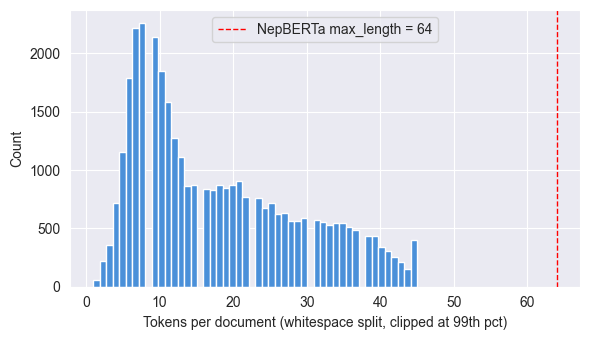


⚠️  0.0% of primary docs exceed 64 tokens and would be truncated.
    If this is a big number, revisit NEPBERTA_MAX_LENGTH in config.py.


In [9]:
# ============================================================================
# TEXT LENGTH DISTRIBUTION  — how long are the documents?
# ============================================================================
#
# CONCEPT: why text length matters
# --------------------------------
# NepBERTa has a `max_length` parameter (default 128 in our config). Any text
# longer than that gets TRUNCATED — the tail is chopped off before the model
# ever sees it. If a review has the sentiment-carrying conclusion at the end
# ('...and overall it was terrible'), we'd miss it. So we need to know: what
# percentage of docs exceed 128 tokens? If it's 40%, we have a problem.
# If it's 2%, we're fine.
#
# We measure length TWO ways:
#  (a) Characters — raw length of the string. Simple, always works.
#  (b) Whitespace-split tokens — rough approximation of 'words'. Not perfect
#      for Devanagari (compound words, etc.) but close enough for shape.
#
# CONCEPT: the `.str` accessor
# ----------------------------
# Pandas Series have a special `.str` attribute that exposes string methods,
# applied element-wise across the column. `.str.len()` = length of each string.
# `.str.split()` = split each string on whitespace into a list. Then `.apply(len)`
# runs Python's built-in `len()` on each resulting list, giving token count.
#
# CONCEPT: `.fillna('')`
# ----------------------
# If a cell is NaN (null), `.str.len()` would return NaN too. We replace nulls
# with empty strings first so length comes out as 0 instead of NaN — keeps the
# output numeric and comparable.

primary_char_lens = primary_raw['Sentences'].fillna('').str.len()
primary_tok_lens  = primary_raw['Sentences'].fillna('').str.split().apply(len)

# ============================================================================
# .describe()  — pandas's built-in summary statistics
# ============================================================================
# `.describe()` is a quick-look report: count, mean, std, min, max, and some
# percentiles. By default it gives 25/50/75 pct but we override to include the
# more useful 90/95/99 percentiles for length analysis.
#
# CONCEPT: PERCENTILES
# --------------------
# The Nth percentile is 'the value below which N% of the data falls'.
# Example: 95th percentile of token count = 150 means '95% of documents have
# <= 150 tokens, and 5% are longer'. Great for setting `max_length`:
# if the 95th pct is 128, a max_length of 128 loses almost nothing.

print('CHARACTER length stats:')
print(primary_char_lens.describe(percentiles=[.5, .9, .95, .99]).round(1))
print()
print('TOKEN length stats (whitespace split):')
print(primary_tok_lens.describe(percentiles=[.5, .9, .95, .99]).round(1))

# ============================================================================
# HISTOGRAM of token counts
# ============================================================================
# CONCEPT: HISTOGRAM
# ------------------
# A histogram divides the range of values into 'bins' (buckets) and counts how
# many data points fall into each. Shape of the histogram tells us where most
# data is concentrated and where the outliers are.
#
# CONCEPT: CLIPPING OUTLIERS FOR DISPLAY
# --------------------------------------
# If one review is 5,000 tokens and most are <100, the plot would be a tall
# bar at 0-100 and a flat line to the right, with the x-axis stretching to
# 5000 — useless. `.clip(upper=X)` caps values at X for plotting purposes
# (doesn't modify the underlying data). We clip at the 99th percentile so
# we see 99% of the data in detail and treat the last 1% as 'very long'.
#
# `.quantile(0.99)` returns the value at the 99th percentile.
cutoff = int(primary_tok_lens.quantile(0.99))

fig, ax = plt.subplots(figsize=(6, 3.5))
# `bins=50` splits the clipped range into 50 buckets. More bins = finer detail,
# fewer bins = smoother shape. 30-50 is the usual sweet spot.
ax.hist(primary_tok_lens.clip(upper=cutoff), bins=50,
        color='#4a90d9', edgecolor='white')

# `axvline` draws a vertical line at a given x position. We use it to mark
# NepBERTa's max_length cap, so we can visually see how much of the data
# falls to the RIGHT of the line (= would get truncated).
ax.axvline(config.NEPBERTA_MAX_LENGTH, color='red', linestyle='--', linewidth=1,
           label=f'NepBERTa max_length = {config.NEPBERTA_MAX_LENGTH}')

ax.set_xlabel('Tokens per document (whitespace split, clipped at 99th pct)')
ax.set_ylabel('Count')
ax.legend()  # shows the label for the red line
plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES, 'text_length_primary.png'),
            dpi=config.FIGURE_DPI)
plt.show()

# Finally, the concrete number we actually care about: what % of docs
# would be truncated at the current max_length?
# `(series > X).mean()` works because True=1, False=0, so the average is
# the fraction of True values. Multiply by 100 -> percentage.
pct_truncated = (primary_tok_lens > config.NEPBERTA_MAX_LENGTH).mean() * 100
print(f'\n⚠️  {pct_truncated:.1f}% of primary docs exceed '
      f'{config.NEPBERTA_MAX_LENGTH} tokens and would be truncated.')
print('    If this is a big number, revisit NEPBERTA_MAX_LENGTH in config.py.')

## ⚠️ These lengths are not what NepBERTa sees

The histogram above measures **whitespace-separated words**. That's the right metric for TF-IDF (sklearn's vectorizer uses a similar word-regex). But NepBERTa doesn't tokenize that way — it uses **WordPiece / BPE subword** tokenization, which typically produces 1.5×–3× more tokens per document.

To set `NEPBERTA_MAX_LENGTH` honestly we need actual BPE counts. Running NepBERTa's tokenizer over ~35k rows needs the `transformers` library (~500MB of deps), which we don't install locally — we offload that analysis to Google Colab.

**Workflow:**

1. Open `notebooks/colab_bpe_length_eda.ipynb` in Google Colab.
2. Run it — it uploads the two raw CSVs, tokenises everything with the real NepBERTa tokenizer, and gives you a summary CSV.
3. Move the downloaded `bpe_length_stats.csv` into `outputs/results/`.
4. Re-run the next cell — it loads that CSV and reports the real BPE statistics alongside a recommended `max_length`.

Until you do that, the whitespace histogram above is a rough proxy — useful shape-wise (short-form data, not a long-review corpus) but not calibrated to NepBERTa.

In [10]:
# ============================================================================
# CONSUME BPE LENGTH STATS  — if the Colab helper has been run
# ============================================================================
#
# This cell looks for outputs/results/bpe_length_stats.csv, produced by
# notebooks/colab_bpe_length_eda.ipynb on Google Colab. If present, we print
# the REAL NepBERTa BPE-token percentiles and suggest a concrete max_length.
# If absent, we print a reminder — the notebook still runs without it.

from pathlib import Path
import math

bpe_stats_path = Path(config.RESULTS) / 'bpe_length_stats.csv'

if not bpe_stats_path.exists():
    # No file yet — just explain what to do. Non-blocking.
    print(f'⚠️  {bpe_stats_path} not found.')
    print('    Run notebooks/colab_bpe_length_eda.ipynb on Colab, then drop the')
    print('    downloaded bpe_length_stats.csv into outputs/results/ and re-run')
    print('    this cell to see the real NepBERTa token-length distribution.')
else:
    bpe_stats = pd.read_csv(bpe_stats_path)
    print('Real NepBERTa BPE token length (from Colab run):')
    print(bpe_stats.to_string(index=False))
    print()

    # Concrete recommendation: round the primary dataset's 99th percentile UP
    # to the nearest multiple of 32. Multiples of 32 are friendlier for GPU
    # tensor-core kernels, so a tiny bit of slack there is free.
    primary_p99 = bpe_stats.loc[bpe_stats['dataset'] == 'primary', 'p99'].iloc[0]
    suggested   = int(math.ceil(primary_p99 / 32) * 32)
    current     = config.NEPBERTA_MAX_LENGTH

    print(f'Current NEPBERTA_MAX_LENGTH (config.py): {current}')
    print(f'Suggested (primary p99 = {primary_p99:.0f}, rounded up to nearest 32): {suggested}')

    if suggested < current:
        saving = (1 - suggested / current) * 100
        print(f'→ Can safely shrink max_length from {current} to {suggested} '
              f'(~{saving:.0f}% less NepBERTa compute per batch).')
    elif suggested > current:
        print(f'→ max_length should be BUMPED from {current} to {suggested} to '
              f'avoid truncating the tail of the data.')
    else:
        print('→ Current max_length is already a good fit.')

Real NepBERTa BPE token length (from Colab run):
dataset  n_rows  mean  median  p90  p95   p99  max  pct_over_64  pct_over_128  pct_over_256
primary   35789 23.22    19.0 44.0 51.0 61.12  103         0.59           0.0           0.0

Current NEPBERTA_MAX_LENGTH (config.py): 64
Suggested (primary p99 = 61, rounded up to nearest 32): 64
→ Current max_length is already a good fit.


In [11]:
# ============================================================================
# NOISE AUDIT  — how much Twitter-style garbage is actually here?
# ============================================================================
#
# CONCEPT: evidence-based cleaning
# --------------------------------
# Every regex we add to clean_text costs CPU time and risks false matches.
# So we only add a regex if the corresponding noise actually appears often.
# Rule of thumb: if <1% of rows contain pattern X, don't bother stripping X.
#
# CONCEPT: REGEX BASICS (the patterns we're using)
# ------------------------------------------------
#   r'https?://\S+'   = 'http', optional 's', then '://', then any run of
#                       non-whitespace characters (= the URL body).
#                       The `r''` means 'raw string' — backslashes aren't
#                       interpreted as escapes. Standard for regex.
#   r'www\.\S+'       = 'www.' followed by non-whitespace. Catches URLs
#                       that don't start with http.
#   r'@\w+'           = '@' followed by one or more word chars (letters/digits/_).
#   r'#\w+'           = same for hashtags.
#   r'[A-Za-z]'       = any Latin letter. Checks for English mixed in.
#   r'\d'             = any digit 0-9.
#   r'[\U0001F300-...'= a range of Unicode code points covering emojis.
#   r'^\s*$'          = start-of-string, zero-or-more whitespace, end-of-string.
#                       Matches 'empty or whitespace-only' rows.
#
# CONCEPT: Series.str.contains(regex)
# -----------------------------------
# Returns a boolean Series: True for every row where the regex matches at least
# once. .sum() counts Trues -> number of rows with that kind of noise.

# `.fillna('')` guards against NaN rows causing errors in str methods.
# `.astype(str)` ensures every element is a string (not a float or mixed).
primary_texts = primary_raw['Sentences'].fillna('').astype(str)

# Shared regex patterns dict — defined once so any future re-run or
# cross-dataset comparison uses IDENTICAL criteria (no accidental drift).
NOISE_PATTERNS = {
    'URLs (http...)':          r'https?://\S+',
    'www. URLs':               r'www\.\S+',
    '@mentions':               r'@\w+',
    '#hashtags':               r'#\w+',
    'Latin letters':           r'[A-Za-z]',
    'Digits':                  r'\d',
    'Emoji-ish symbols':       r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]',
    'Empty / whitespace only': r'^\s*$',
}

# Table header — nicely aligned with f-string width specifiers.
print(f'Total rows: {len(primary_texts)}')
print(f"{'Pattern':<28}{'rows w/ ≥1 match':>18}{'%':>9}")
print('-' * 56)

# Iterate over the dict's (name, pattern) pairs, count matches, print row.
for name, pat in NOISE_PATTERNS.items():
    n = primary_texts.str.contains(pat, regex=True, na=False).sum()
    print(f'{name:<28}{n:>18}{n/len(primary_texts)*100:>8.1f}%')

Total rows: 35789
Pattern                       rows w/ ≥1 match        %
--------------------------------------------------------
URLs (http...)                               0     0.0%
www. URLs                                    0     0.0%
@mentions                                    0     0.0%
#hashtags                                    0     0.0%
Latin letters                                0     0.0%
Digits                                      55     0.2%
Emoji-ish symbols                            1     0.0%
Empty / whitespace only                      0     0.0%


In [12]:
# ============================================================================
# SCRIPT MIX  — how Devanagari-pure is the text?
# ============================================================================
#
# CONCEPT: Unicode blocks and scripts
# -----------------------------------
# Every character has a Unicode 'code point' (a number). These numbers are
# organised into BLOCKS by script — e.g., Devanagari lives in U+0900 to U+097F.
# That range covers Nepali + Hindi + Sanskrit consonants, vowels, diacritics,
# and digits. Any character in that range is Devanagari; anything outside is
# something else (Latin, digits, punctuation, emoji, etc.).
#
# Why we care: if a row is 90% Devanagari and 10% Latin (say, an English brand
# name or a hashtag), stripping ALL non-Devanagari is probably fine. But if
# rows are 50/50 mixed, aggressive stripping would destroy half the content.
# EDA tells us which scenario we're in.

def char_breakdown(s: str) -> dict:
    """Return the fraction of each character type in a single string.

    DONKEY: imagine we pour every character of the string into one of five
    buckets (devanagari / latin / digit / whitespace / other), then compute
    'what fraction of characters ended up in each bucket'. Result sums to 1.0.
    """
    # `sum(1 for c in s if condition)` is a 'generator expression' — a compact
    # way to count without building an intermediate list. Faster than a loop
    # with an incrementing counter.
    dev = sum(1 for c in s if '\u0900' <= c <= '\u097F')  # Devanagari block
    lat = sum(1 for c in s if c.isascii() and c.isalpha())  # plain a-z / A-Z
    dig = sum(1 for c in s if c.isdigit())
    ws  = sum(1 for c in s if c.isspace())
    other = len(s) - dev - lat - dig - ws  # everything else (punct, symbols)
    total = max(len(s), 1)  # guard against division-by-zero on empty strings
    return {'devanagari': dev/total, 'latin': lat/total,
            'digit': dig/total, 'whitespace': ws/total, 'other': other/total}

# Running this on every row would be slow (Python-level loop per char, per row).
# A 5,000-row sample is more than enough to see the shape of the distribution.
#
# `.apply(char_breakdown)` runs our function on each text, returning a Series
# of dicts. `.apply(pd.Series)` then EXPANDS each dict into its own columns,
# turning the Series of dicts into a proper DataFrame we can take .mean() of.
sample = primary_texts.head(5000).apply(char_breakdown).apply(pd.Series)

# `.mean()` averages each column -> the typical fraction of each character
# type in a row. Multiply by 100 and format as string with '%' sign for
# readable output.
print('Average character-type fractions across first 5,000 rows:')
print((sample.mean() * 100).round(2).astype(str) + ' %')

Average character-type fractions across first 5,000 rows:
devanagari    85.19 %
latin           0.0 %
digit          0.03 %
whitespace     14.6 %
other          0.17 %
dtype: object


In [13]:
# ============================================================================
# SAMPLE ROWS PER CLASS  — eyeball the actual content
# ============================================================================
#
# WHY THIS STEP MATTERS:
# Counts and histograms tell us NUMBERS. They can't tell us whether the text
# is actually SENSIBLE. Common things we catch here that stats miss:
#   - sarcasm labelled as positive ('wow, great job breaking everything')
#   - one-word rows ('राम्रो') where no context means labelling is arbitrary
#   - mislabelled rows (obviously angry text labelled neutral)
#   - non-Nepali text sneaking in (pure English that somehow passed the filter)
#   - garbage rows (HTML tags, control characters, broken encoding)
#
# Reading 3 examples per class takes 30 seconds and sometimes reveals a data
# problem that would have taken hours to debug later in training.
#
# CONCEPT: BOOLEAN INDEXING
# -------------------------
# `df[df['col'] == value]` is pandas's 'filter' syntax. The inner part
# (df['col'] == value) produces a boolean Series (True/False per row); the
# outer df[...] keeps only rows where that Series is True. Think of it as
# SQL's WHERE clause.

# `.dropna()` removes nulls before we iterate over unique labels (can't sort
# a list containing NaN). `.unique()` returns a numpy array of distinct values.
# `sorted(...)` puts them in order so output is reproducible.
for lbl in sorted(primary_raw['Sentiment'].dropna().unique()):
    print(f'\n─── label = {lbl} ───')
    samples = primary_raw[primary_raw['Sentiment'] == lbl]['Sentences'].head(10)
    for i, txt in enumerate(samples):

        print(f'  [{i+1}] {txt}')


─── label = -1 ───
  [1] उपनियाशमा चलचित्र बनाउदा सबैको बुचार गरेर बनाको भय राम्रो हुने थियो कलकार छनोट अनि उमेरमा धेरै फरक परेको छ जस्तो बसन्ती चलचित्र जस्तो बन्न सकेन
  [2]  नेपालमा बनेको अहिले सम्मको सबै भन्दा खाते फिल्म यहि हो !!! के सोचेर यस्तो हावादारि छेउ न टुप्पोको फिल्म बनाको होला । 
  [3] कठै बिचारा कस्तो निर्देशक कस्ता कलाकार, इतिहास लाई मजाक बनाइदिने पहिला अध्यान त गर्नु , हावा को भर मा फिल्म बनाउने अनि काहा बाट पाहुछ हल मा दर्शक छि छि छि छि लाज लाग्यो मलाई किताब पढेर फिल्म हेर्दा
  [4] कथा हरु मा केही ठिक भए पनि कलाकार पात्र हरु कुनै राम्रो भएन
  [5] खै के भनु फिल्म त राम्रो लागेन , अलि राम्रो कलाकार लिएर बनाउनु पने थियोे
  [6] बाटो बाट टीपेर ल्यको कलाकार हरू हो कि क्या हो?! डाइमंड शमशेर को किताब को बेज्जत।
  [7] कथा बस्तु राम्रो लागेन मलाई त पहिलो भाग नै उतम थियो यो उचित लागेन।
  [8] अहिले सम्मको झल्लो फिल्म राम्रो नि लागेन
  [9] कस्तो आलु जस्तो मोभी प्रतीप को मोभी धेरै हेरे तर कुनै राम्रो लागेन
  [10] पर्दिप को यो फिलिम चाई पागल जस्तो छ कस्तो फिल्म खेलेको यत्रो सुपर स्ट

## What this EDA tells us about preprocessing

Now the fun part: use the OUTPUT above (not imagination, not blog posts) to decide what `clean_text` should actually do. Tick each box once you've read the relevant cell's output.

### Data-shape decisions
- [ ] **Nulls** — how many rows disappear if we drop text-or-label nulls? (usually safe to drop.)
- [ ] **Duplicates** — drop before or after the train/test split? (Rule: BEFORE, to avoid leakage.)
- [ ] **Conflicting labels** — we have 19 texts with ≥2 different labels. Pick a resolution strategy (majority vote / drop / manual).
- [ ] **Label format** — confirm `{-1, 0, 1}` maps cleanly via `LABEL_MAP`.

### Cleaning-rule decisions (>1% of rows = keep regex; <0.1% = skip it)
- [ ] **URLs (http + www)** — strip? How frequent?
- [ ] **@mentions** — strip?
- [ ] **#hashtags** — drop `#` but keep the word, or strip whole token?
- [ ] **Latin letters** — keep (common code-mixing) or strip (purity)?
- [ ] **Digits** — keep (dates, numbers can carry meaning) unless clearly spammy.
- [ ] **Emoji** — replace with placeholder, drop, or keep? Nepali social media often uses them.

### Model-setting decisions
- [ ] **`NEPBERTA_MAX_LENGTH`** — final value after the Colab BPE tokenizer run (see `colab_bpe_length_eda.ipynb`). The whitespace histogram is only a proxy.
- [ ] **Class imbalance** — is the majority class >50%? Confirms need for `class_weight='balanced'`.

### Story-level findings for the report
- [ ] Any unexpected discoveries (dataset quirks, mislabelled rows, encoding issues)?
- [ ] Note the scope: we work on a single dataset (aayamoza). Cross-dataset generalisation is future work.

Once these are answered, we write `preprocessing.py` with ONLY the rules the data justifies — nothing speculative, nothing copy-pasted from an English NLP tutorial.